In [27]:
from application.simulation_engine import make_model,run_sweep

In [28]:

import matplotlib.pyplot as plt
from utilities.block_builders import *
from training.dataset_generator import flatten_sweep_results_to_batch

model_sur = make_model("surrogate", BSW=0.20, GOR=0.05, PI=3.0e-6)

In [29]:
# --- NEW NOTEBOOK CELL 2: build truth dataset from sweep (ground truth states
#
#
#
y_guess_sur = np.array([3285.42, 300.822, 6910.91], dtype=float)
# Example: define your grids
# (keep consistent with your previous training range unless you want extrapolation)
u1_grid_train = np.linspace(0.05, 1.0, 21)
u2_grid_train = np.linspace(0.10, 1.0, 21)

results_train = run_sweep(
    model_sur,
    u1_grid=u1_grid_train,
    u2_grid=u2_grid_train,
    y_guess_init=y_guess_sur,   # e.g. self.y_guess_surr
    z_guess_init=None,
)

batch_train = flatten_sweep_results_to_batch(results_train, only_success=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
u_data_train = batch_train["u_t"].to(device)  # (N,2)
y_data_train = batch_train["y_t"].to(device)  # (N,3)

print("u_data_train:", u_data_train.shape)
print("y_data_train:", y_data_train.shape)


----------------------------------
u1=1.0 u2=1.0
IPOPT success: True
IPOPT status : Solve_Succeeded
Accepted. y*: [3584.3, 323.702, 6341.33] ||dx||: 2.144656642799556e-14 stable: True

----------------------------------
u1=1.0 u2=0.955
IPOPT success: True
IPOPT status : Solve_Succeeded
Accepted. y*: [3541.74, 320.874, 6406.96] ||dx||: 3.831771963882999e-13 stable: True

----------------------------------
u1=1.0 u2=0.9099999999999999
IPOPT success: True
IPOPT status : Solve_Succeeded
Accepted. y*: [3498.65, 317.902, 6477.36] ||dx||: 5.449226593420245e-13 stable: True

----------------------------------
u1=1.0 u2=0.865
IPOPT success: True
IPOPT status : Solve_Succeeded
Accepted. y*: [3455.17, 314.775, 6552.99] ||dx||: 7.164777646480919e-13 stable: True

----------------------------------
u1=1.0 u2=0.82
IPOPT success: True
IPOPT status : Solve_Succeeded
Accepted. y*: [3411.49, 311.482, 6634.42] ||dx||: 9.914698393241315e-13 stable: True

----------------------------------
u1=1.0 u2=0.774

In [30]:
# --- NEW NOTEBOOK CELL 3: load AlgNN and compute outputs (m_o_out, p_bh, p_tb_b) ---

algnn_path = "training/AlgNN.pth"  # <-- adjust if needed
algnn = rebuild_algnn_from_weights(algnn_path, device=device)

with torch.no_grad():
    z_pred = algnn(y_data_train, u_data_train)  # (N,3)

m_o_out = z_pred[:, 0].detach().cpu().numpy()
p_bh    = z_pred[:, 1].detach().cpu().numpy()
p_tb_b  = z_pred[:, 2].detach().cpu().numpy()

u_cpu = u_data_train.detach().cpu().numpy()
u1 = u_cpu[:, 0]
u2 = u_cpu[:, 1]

print("z_pred:", z_pred.shape)

=== LOADING STATE_DICT FROM Training/AlgNN.pth ===
Rebuilt AlgNN: n_out=3, hidden_units=[64, 64, 64, 64]
z_pred: torch.Size([441, 3])


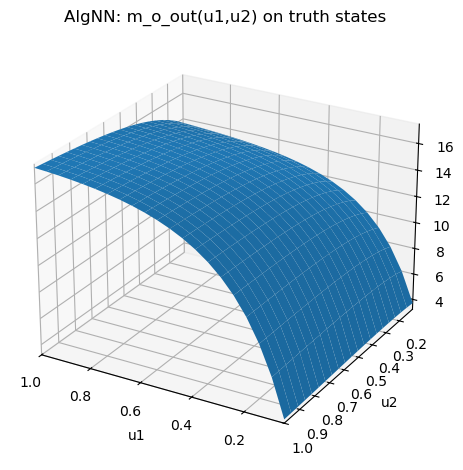

In [31]:
# --- NEW NOTEBOOK CELL 4: plot m_o_out over (u1,u2) ---
# If the sweep grid is perfectly rectangular, we can reshape to a surface.
# If not (missing points because only_success=True), we use triangulation.

def plot_surface_or_trisurf(u1, u2, z, title, zlabel):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    # Try grid reshape if it looks like a full cartesian product
    u1_unique = np.unique(u1)
    u2_unique = np.unique(u2)
    full = (u1_unique.size * u2_unique.size == u1.size)

    if full:
        U1, U2 = np.meshgrid(u1_unique, u2_unique, indexing="xy")

        # Build a mapping (u1,u2)->z and fill grid
        Z = np.empty_like(U1, dtype=float)
        idx = {(a, b): i for i, (a, b) in enumerate(zip(u1, u2))}
        for j in range(U2.shape[0]):
            for i in range(U1.shape[1]):
                Z[j, i] = z[idx[(U1[j, i], U2[j, i])]]

        ax.plot_surface(U1, U2, Z, linewidth=0, antialiased=True)
        ax.set_xlim(U1.max(), U1.min())  # optional: (1,1) closest corner
        ax.set_ylim(U2.max(), U2.min())
    else:
        # Works even with missing points
        ax.plot_trisurf(u1, u2, z, linewidth=0.2, antialiased=True)

    ax.set_xlabel("u1")
    ax.set_ylabel("u2")
    ax.set_zlabel(zlabel)
    ax.set_title(title)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

plot_surface_or_trisurf(u1, u2, m_o_out, title="AlgNN: m_o_out(u1,u2) on truth states", zlabel="m_o_out")